<a href="https://colab.research.google.com/github/DiegoLopezAroca/Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry/blob/main/Advanced_ML_D2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Advanced ML - D2.2: Final submission**
In this final submission of, we will apply all the forecasting material seen in class to the dataset covered in the previous delivery. We will go over each section required, providing code and the corresponding explaination at each time.

This delivery, plus all the previous work carried with the selected dataset will be available in the following GitHub repository link. [``Github repository``](https://github.com/DiegoLopezAroca/Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry).

## **Steel Industry Energy Consumption**
Sourced and available from the well known *UCI Machine Learning Repository*, the selected dataset collects the energy consumption data over time from a company in charge of manufacturing different steel pieces such as coils, steel and iron plates.

<img src="https://imgs.search.brave.com/ESvN_gCRRKdWbUcO7p8AkLrhO1BaXxMl-yZXC8V-Plg/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNjYv/MzY5LzQxOS9zbWFs/bC9pbmR1c3RyaWFs/LW1ldGFsLXdpcmUt/Y29pbHMtY29pbHMt/b2YtbWV0YWwtd2ly/ZS1hcmUtc3RhY2tl/ZC1vbi1hLWxvYWRp/bmctZG9jay1pbi1h/LWxhcmdlLWluZHVz/dHJpYWwtZmFjaWxp/dHktZHVyaW5nLWRh/eWxpZ2h0LWhvdXJz/LXBob3RvLmpwZw" width="250">

<img src="https://imgs.search.brave.com/PZ3OMLbjSqIO4KVhCtt7duTpXzryO8z7jjU3yPuUIuI/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNzEv/NDYzLzI4NC9zbWFs/bC9zdGFjay1vZi1z/dGVlbC1wbGF0ZXMt/aW5kdXN0cmlhbC1t/ZXRhbC1zaGVldHMt/bWV0YWwtY29uc3Ry/dWN0aW9uLW1hdGVy/aWFscy1jbG9zZS11/cC1waG90by5qcGc" width="250">

We won't cover the dataset analysis as that work was already tackled in the previous submission.


# Dataset loading & Dependencies

In [1]:
#from pydrive2.auth import GoogleAuth
#from pydrive2.drive import GoogleDrive
#from google.colab import auth
#from oauth2client.client import GoogleCredentials
#from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from typing import Union
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox
import torch
from chronos import ChronosPipeline
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
#auth.authenticate_user()
#google_auth = GoogleAuth()
#google_auth.credentials = GoogleCredentials.get_application_default()
#drive = GoogleDrive(google_auth)
#file_id = '1FLKVRjZcWCm3zBcNElhfEZm3KAzRW3PQ'
#file = drive.CreateFile({'id':file_id})
#file.GetContentFile('steel_industry_energy_dataset.csv')

df = pd.read_csv('data/Steel_industry_data.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


As in the previous submission, we will cast the required variables to work with datetime feature types.

In [3]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
df.set_index("date", inplace=True)
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
date,,,,,,,,,,
2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


# 1. Time Series Analysis
Even if we already covered part of this analysis in the previous work, we will still include it for a more compact study on the forecasting properties of the dataset. Furthermore, we would like to clear some of the previous analysis which may have been a little confusing.

In the analysis part we will also work with hourly data, which could help us find long term tendencies more easily albeit we won't use it in the forecasting techniques.

In [4]:
print(df["Load_Type"].unique())
print(df["WeekStatus"].unique())
df['WeekStatus'] = df['WeekStatus'].map({'Weekday': 0, 'Weekend': 1})
df["Load_Type"] = df['Load_Type'].map({'Light_Load': 0, 'Medium_Load': 1, 'Maximum_Load': 2})
df['Day_of_week'] = df.index.dayofweek

<StringArray>
['Light_Load', 'Medium_Load', 'Maximum_Load']
Length: 3, dtype: str
<StringArray>
['Weekday', 'Weekend']
Length: 2, dtype: str


In [5]:
df.iloc[100:105]

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
date,,,,,,,,,,
2018-01-02 01:15:00,3.89,4.72,0.0,0.0,63.60,100.0,4500,0,1,0
2018-01-02 01:30:00,3.28,3.53,0.0,0.0,68.07,100.0,5400,0,1,0
2018-01-02 01:45:00,3.46,3.96,0.0,0.0,65.80,100.0,6300,0,1,0
2018-01-02 02:00:00,3.78,4.82,0.0,0.0,61.71,100.0,7200,0,1,0
2018-01-02 02:15:00,3.31,3.53,0.0,0.0,68.40,100.0,8100,0,1,0


In [6]:
reglas_agrupacion = {
    'Usage_kWh': 'sum',
    'Lagging_Current_Reactive.Power_kVarh': 'sum',
    'Leading_Current_Reactive_Power_kVarh': 'sum',
    'CO2(tCO2)': 'sum',
    'Lagging_Current_Power_Factor': 'mean',
    'Leading_Current_Power_Factor': 'mean',
    'Day_of_week': 'first',
    'WeekStatus': 'first',
    'Load_Type': 'first'
}

df_hourly = df.resample('h').agg(reglas_agrupacion)
df_hourly.iloc[100:105]


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,Day_of_week,WeekStatus,Load_Type
date,,,,,,,,,
2018-01-05 04:00:00,18.55,19.26,0.0,0.00,69.3800,100.0,4,0,0
2018-01-05 05:00:00,18.50,19.51,0.0,0.00,68.8100,100.0,4,0,0
2018-01-05 06:00:00,18.50,19.26,0.0,0.00,69.2750,100.0,4,0,0
2018-01-05 07:00:00,21.49,20.13,0.0,0.00,72.2100,100.0,4,0,0
2018-01-05 08:00:00,295.48,179.10,0.0,0.13,84.4825,100.0,4,0,0


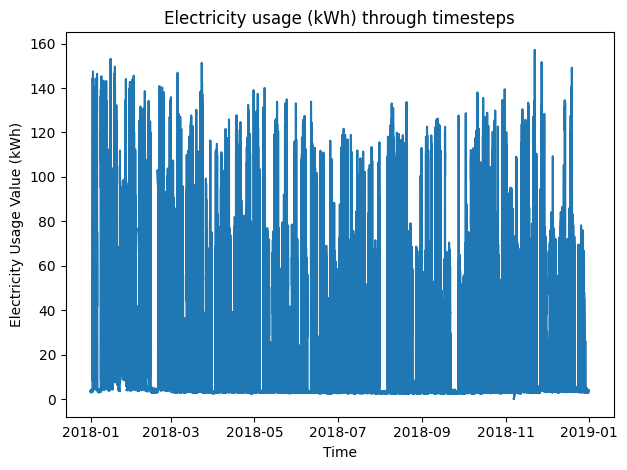

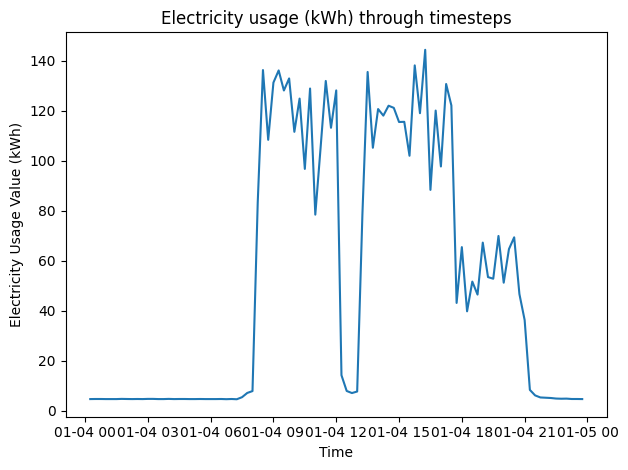

In [7]:
def visualize_time_series(dataframe):
    fig, ax = plt.subplots()
    ax.plot(dataframe.index, dataframe["Usage_kWh"])
    ax.set_xlabel('Time') # Is just the sequential order
    ax.set_ylabel('Electricity Usage Value (kWh)')
    plt.title("Electricity usage (kWh) through timesteps")
    plt.tight_layout()

visualize_time_series(df)
visualize_time_series(df[(df.index < "2018-01-5") & (df.index > "2018-01-4")])


As we can deduce from the plots, every day this plant seems to have a sudden drop between 11 and 12 hour and every day the plant is completely shut down.

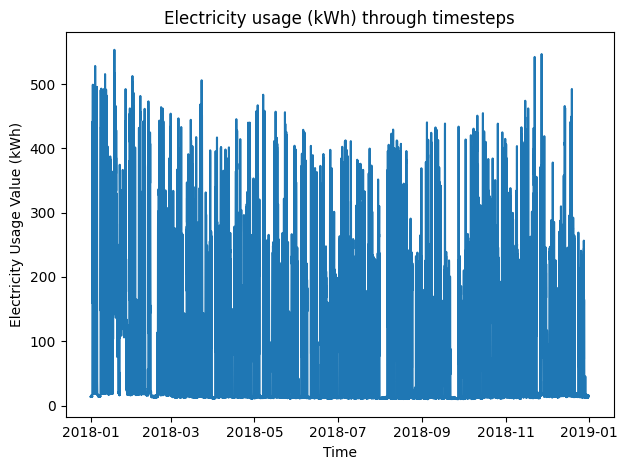

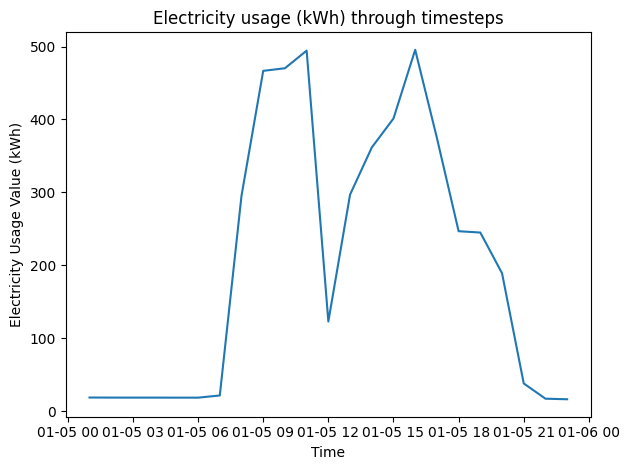

In [8]:
visualize_time_series(df_hourly)
visualize_time_series(df_hourly[(df_hourly.index < "2018-01-6") & (df_hourly.index > "2018-01-5")])

In [8]:
ADF_result = adfuller(df['Usage_kWh']) # Apply to the time series column
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]:.4f}')

ADF Statistic: -24.281836827446362
p-value: 0.0000


As the p-value is less than 0.05 we can reject the null hypothesis and confirm that the time series is stationary (constant mean and variance). But as we looked more into it we saw that the lag in autocorrelation was decaying suprisingly slow. This suggests that there could be a random walk not being detected because the way in which the plant is shutted down every day is biasing the test. (Although this is neglected in the PADF test)

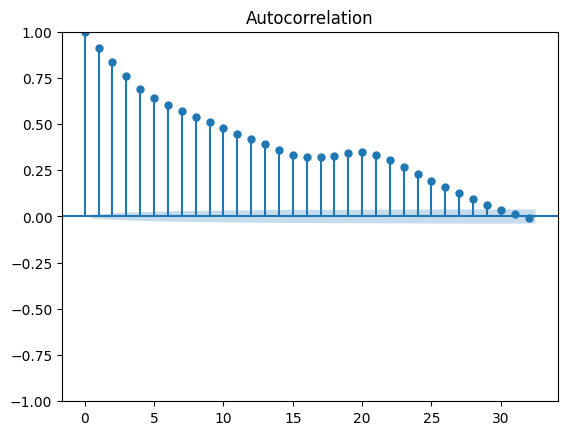

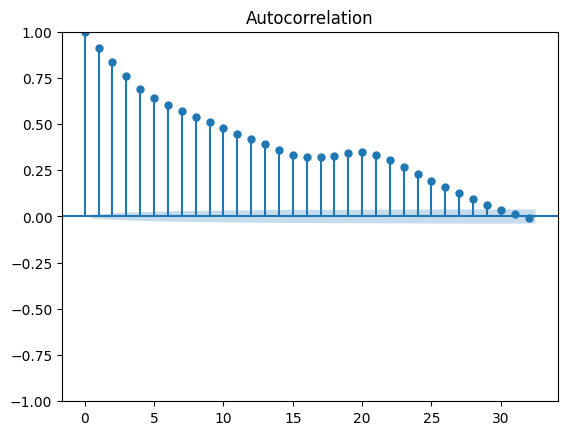

In [9]:
plot_acf(df['Usage_kWh'], lags=32)

Its curious to see that the lag is so big. This has lead us to think that maybe the adf test was being affected by the fact that each day the production plant is completely shut down (this is sustained by the fact of the linear decay that the plot shows, which indicates the presence of a trend). To prove that, we can analyze the partial autocorrelation. While the standard ACF showed a slow decay, the PACF shows the direct relationship between a timestamp and its previous lags, removing the influence of intermediate steps.

Doing this we can affirm that this is not an moving average process and therefore we have to prove whether is an autoregresive process or not.

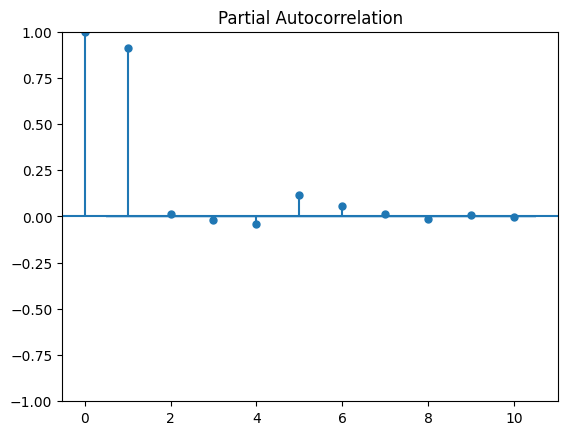

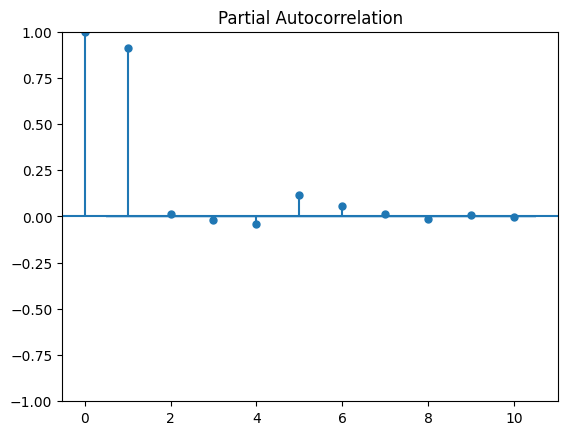

In [11]:
plot_pacf(df['Usage_kWh'], lags=10)

The fact that the PACF falls suddenly after the first lag confirms that the present value is linearly dependent on its own past value and we can infer that p=1 and therefore the coefficients are significant up until lag p only. In this case, as the coefficients become abruptly non-significant after lag 1 then we can say that its an autoregressive process and the hypothesis of having an ARMA process is rejected.

### Decomposition of the time series

In this part we will apply decomposition techniques to determine the precense of trends, seasonality and residuals. To begin with this the usage plots will be divided with red lines, each representing a month. We will use a period of 96, as there are 96 intervals of 15 minutes in a day.

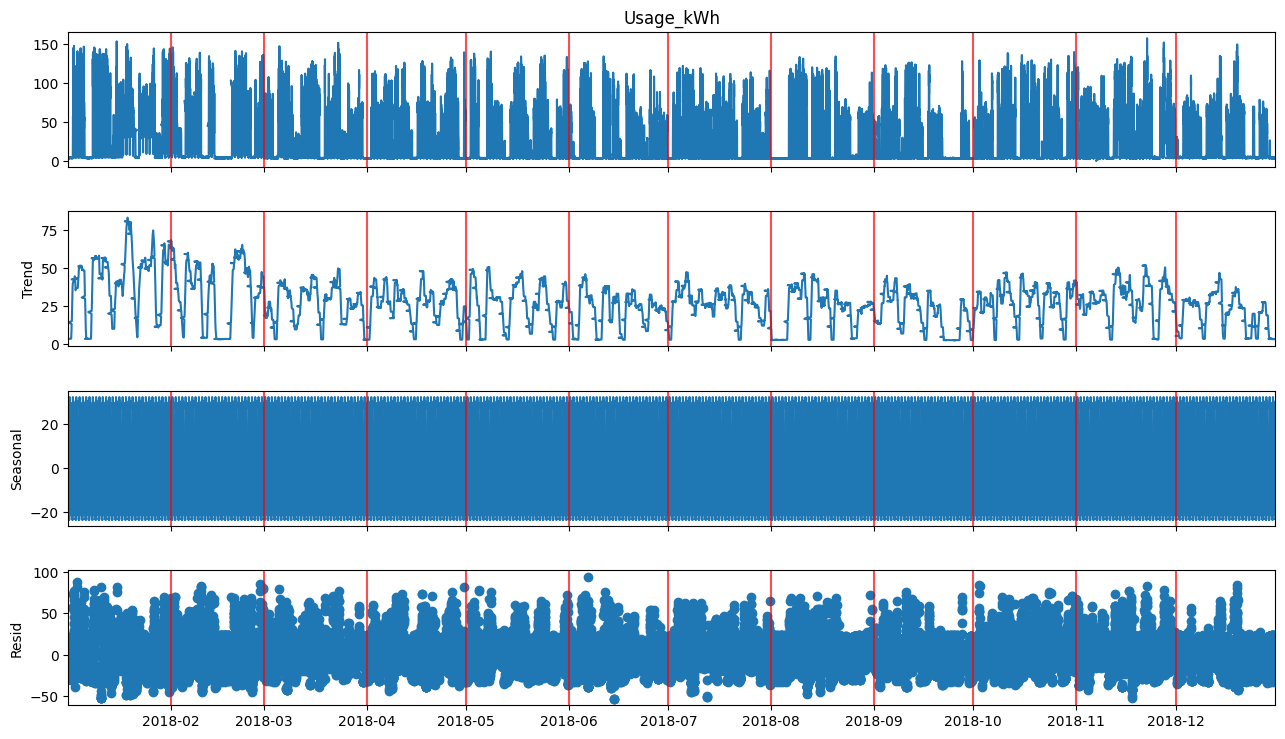

In [9]:
def decomposing(df, period):
    decomposition = seasonal_decompose(df['Usage_kWh'], model='additive', period=period)    
    fig = decomposition.plot()
    fig.set_size_inches(14, 8)
    months = df.index.month.unique()
    for month in months:
        fecha_inicio_año = pd.Timestamp(f'2018-{month}-01')
        for ax in fig.axes:
            ax.axvline(x=fecha_inicio_año, color='red', linestyle='-', alpha=0.7)
    plt.show()

decomposing(df, 96)

The data is not very conclusive, let's see if in hourly time periods we can extract how do they affect in a week.

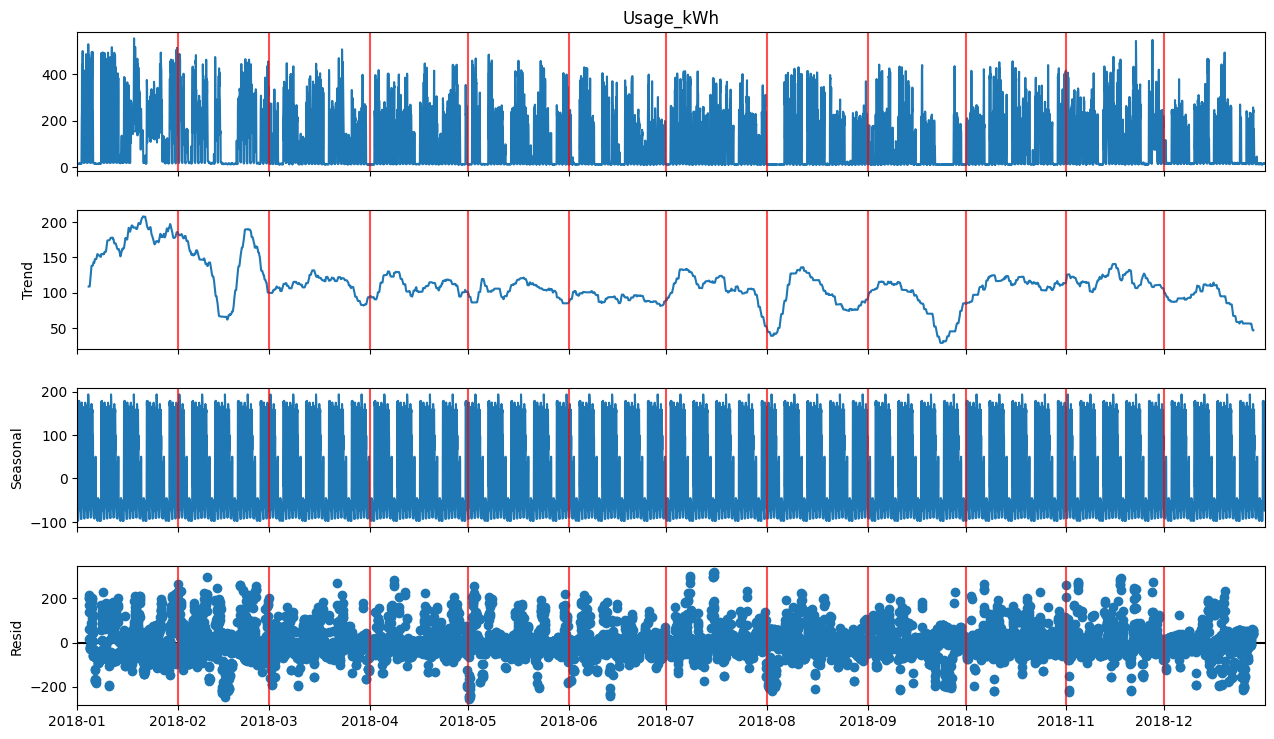

In [13]:
decomposing(df_hourly, 168)

Continuing with the analysis, this plots are not easy to understand.
On the one hand, we could say that there is a kind of electricity usage reduction in months like July, August and December, which makes sense, having that these could be vacation periods. Despite this, as our analisys is mostly focused on short period of times this is not really helpful.

On the other hand, we can see in the seasonal plot that every month there are 4 times where the usage is around 0, which means that this plant shuts down every weekend.

## Dataset Splitting
As mentioned in the previous delivery, our goal is to predict the future 24h electric consumption based on the 15 minutes intervals, recorded during the day for one complete year. The rationale behind this decision is that a 24 hour horizon permits the factory/plant to adjust their production times based on the cost of energy and ensure that the renewable energy supply is enough.

In order to perform the train/test dataset splitting, we must ensure we take the test set as 15 minute intervals of the last 24 hour recordings of our dataset. The number of points or instances that will go directly to the test set can be calculated like: **24 (hours) * 60 (minutes/hour) / 15 (minutes per interval) = 96**. Then, 96 instances will go to the test set, while all the rest will go to the training set.

In [10]:
test_size = int(24 * 60 / 15)
print(f"Number of test instances: {test_size}")

train_size = len(df) - test_size
print(f"Number of train instances: {train_size}")

# Dataset splitting method we have seen in class
train = df.iloc[:train_size]
test = df.iloc[train_size:] # Start test set from the end of the train set

print(f"Total data points: {len(df)}")
print(f"\nTrain data start: {train.index.min()} / end: {train.index.max()}")
print(f"Test data start: {test.index.min()} / end: {test.index.max()}")

Number of test instances: 96
Number of train instances: 34944
Total data points: 35040

Train data start: 2018-01-01 00:00:00 / end: 2018-12-30 23:45:00
Test data start: 2018-12-31 00:00:00 / end: 2018-12-31 23:45:00


Once splitted the dataset into the desired format, let's visualize it once again but differencing the train and test sets.

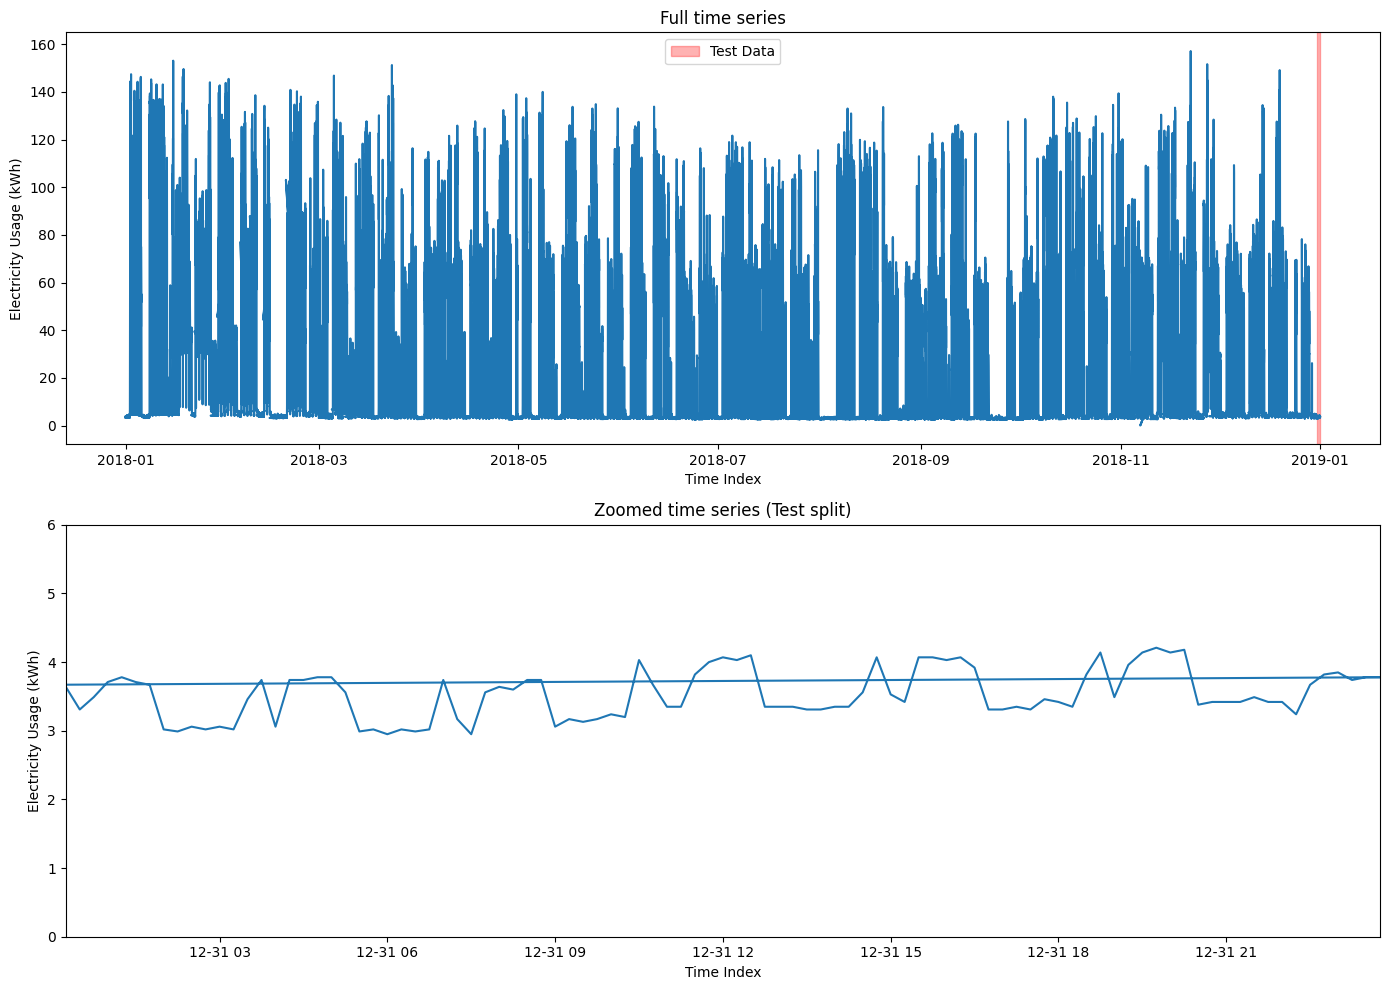

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=False, figsize=(14, 10))

split_date = df.index[train_size]
final_date = df.index.max()

ax1.plot(df.index, df["Usage_kWh"])
ax1.set_xlabel("Time Index")
ax1.set_ylabel('Electricity Usage (kWh)')
ax1.set_title('Full time series')
ax1.axvspan(split_date, final_date, color='r', alpha=0.3, label='Test Data')
ax1.legend()

ax2.plot(df.index, df["Usage_kWh"])
ax2.set_xlabel("Time Index")
ax2.set_ylabel('Electricity Usage (kWh)')
ax2.set_title('Zoomed time series (Test split)')
zoom_start_index = train_size
if zoom_start_index < 0: 
    zoom_start_index = 0

date_zoom_start = df.index[zoom_start_index]

ax2.set_xlim(date_zoom_start, final_date) 
ax2.set_ylim(0, 6)
plt.tight_layout()
plt.show()


As showed in the previous graphs the test set takes a tiny part of the whole time series, so we have plotted a second graph to see more in detail the portion the test set will have.

It's funny, because the last day that we have at our disposal is New Year's Eve, meaning that the plant is not working almost at all. But to our surprise we can see some little spikes every 4 hours which could mean periodic automatic maintenance cycles typical of an industrial plant: thermal preservation of furnaces (kept at minimum temperature to avoid costly restarts), anti-freeze circulation of cooling water systems, or scheduled checks of safety and ventilation equipment. The base consumption of 3 kWh confirms the plant is essentially shut down, with these small spikes representing nothing more than the residual consumption of an automated facility keeping itself.

# AR

In this case we will start doing an autoregressive forecast because we have already identified that we are facing this kind of process. First we make a function comparing the predictions using the mean, the last seen value and the autoregressive process. For the last one we used an order of 1,0,0 which basically means that p=1, d=0 and q=0 (AR parameters, differences, and MA parameter).

p determines the number of past values that affect the present value and the PACF showed us that just 1 value (and obviously itself) was affecting the present prediction and for that reason we setted p=1 (although the default is an AR(1) model: (1,0,0) so it shouldn't be necessary to write it explicitly).

In [17]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
        for i in tqdm(range(train_len, total_len, window)):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in tqdm(range(train_len, total_len, window)):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value

    elif method == 'AR':
        pred_AR = []
        for i in tqdm(range(train_len, total_len, window)):
            model = SARIMAX(df[:i], order=(1,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
        return pred_AR

After that, we have selected a window size of 2 because among the ones we tried is the one which best performs in MAE and MAPE metric terms. This means that we are fundamentaly refitting every half an hour to get the best results.

In [18]:
TRAIN_LEN = train_size
HORIZON = test_size
WINDOW = 2

# We extract the endogenous variable and convert it into a DataFrame
# (type expected by the method) 
target_df = df[['Usage_kWh']]

pred_mean = rolling_forecast(target_df, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(target_df, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_AR = rolling_forecast(target_df, TRAIN_LEN, HORIZON, WINDOW, 'AR')

test = test.copy()

test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR
test.head()

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,pred_mean,pred_last_value,pred_AR
date,,,,,,,,,,,,,
2018-12-31 00:15:00,3.64,2.34,0.00,0.0,84.12,100.00,900,0,0,0,27.452428,3.10,2.938641
2018-12-31 00:30:00,3.31,2.20,0.11,0.0,83.28,99.94,1800,0,0,0,27.452428,3.10,2.785680
2018-12-31 00:45:00,3.49,2.48,0.22,0.0,81.52,99.80,2700,0,0,0,27.451055,3.31,3.137710
2018-12-31 01:00:00,3.71,2.84,0.18,0.0,79.41,99.88,3600,0,0,0,27.451055,3.31,2.974388
2018-12-31 01:15:00,3.78,2.84,0.22,0.0,79.95,99.83,4500,0,0,0,27.449690,3.71,3.516889


In [19]:
mse_mean = mean_squared_error(test['pred_mean'], test['Usage_kWh'])
mse_last = mean_squared_error(test['pred_last_value'], test['Usage_kWh'])
mse_AR = mean_squared_error(test['pred_AR'], test['Usage_kWh'])
print(mse_mean, mse_last, mse_AR)

mape_mean = mean_absolute_percentage_error(test['pred_mean'], test['Usage_kWh'])
mape_last = mean_absolute_percentage_error(test['pred_last_value'], test['Usage_kWh'])
mape_AR = mean_absolute_percentage_error(test['pred_AR'], test['Usage_kWh'])
print(mape_mean, mape_last, mape_AR)

570.7704074798464 0.12248749999999999 0.20192611998692342
0.8711837116371169 0.0669927490744945 0.11985375184052016


The above results will be discussed in more deeply in the last 'Results discussion' part. However, at first glance we can say that the best performer is the last seen value based predictor.

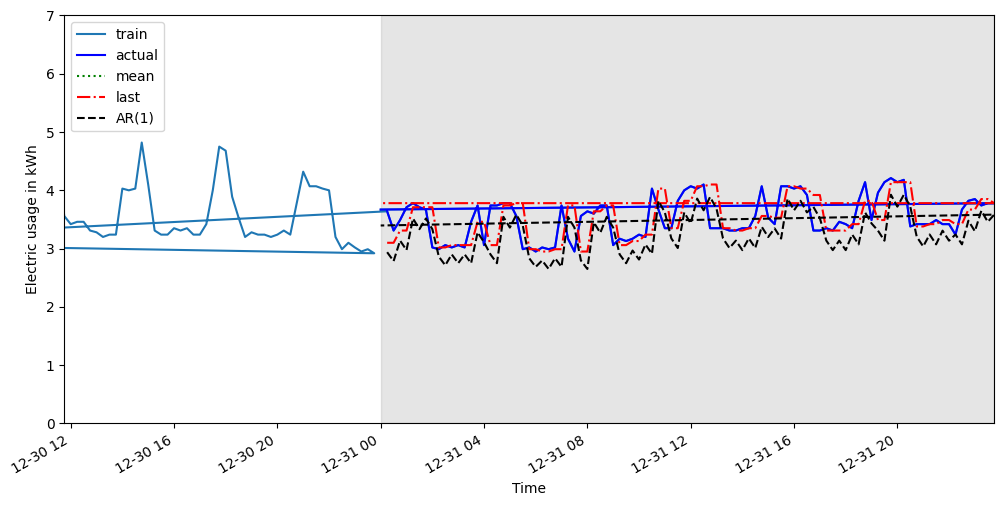

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Usage_kWh'], label='train')
ax.plot(test.index, test['Usage_kWh'], 'b-', label='actual')
ax.plot(test.index, test['pred_mean'], 'g:', label='mean')
ax.plot(test.index, test['pred_last_value'], 'r-.', label='last')
ax.plot(test.index, test['pred_AR'], 'k--', label='AR(1)')

ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Electric usage in kWh')

ax.axvspan(test.index.min(), test.index.max(), color='#808080', alpha=0.2)

zoom_start_date = df.index[-(len(test) + 50)]
ax.set_xlim(zoom_start_date, test.index.max())
ax.set_ylim(0, 7)
fig.autofmt_xdate()
plt.show()


The mean just vanishes from the plot as it's 27.452428. On the other hand, in order to understand better the plot, we will just show how AR(1) is doing.

Ignore the fact that there is a kind of strange change/jump in the consumption of electricity, this propably a problem of how the data was gathered and put together. (See the plot below)

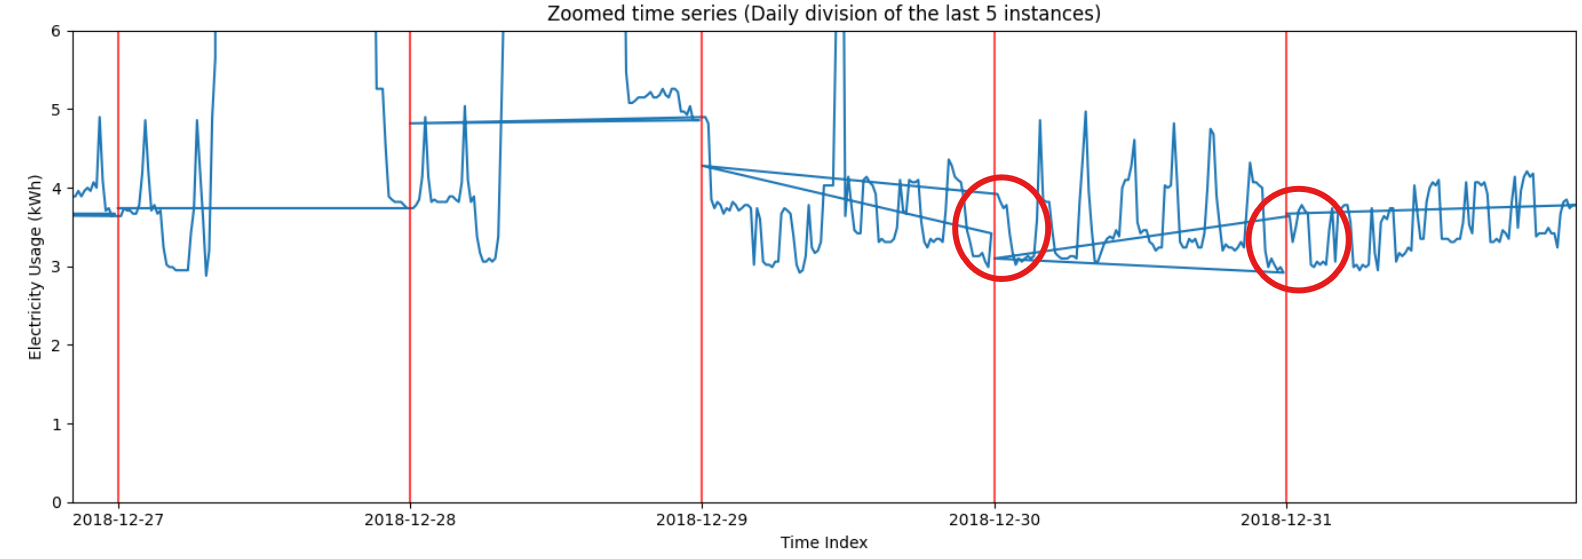

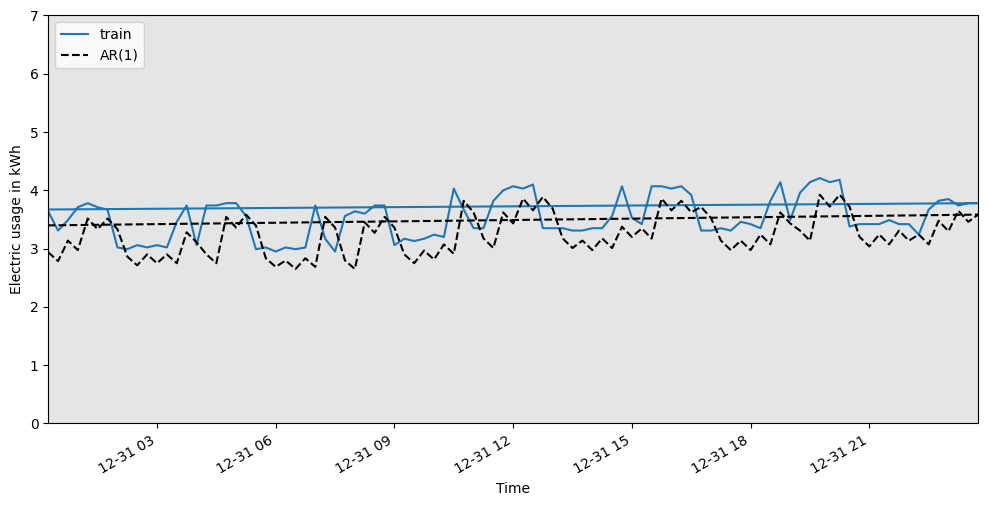

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Usage_kWh'], label='train')
ax.plot(test.index, test['pred_AR'], 'k--', label='AR(1)')

ax.legend(loc='upper left')
ax.set_xlabel('Time')
ax.set_ylabel('Electric usage in kWh')

ax.axvspan(test.index.min(), test.index.max(), color='#808080', alpha=0.2)

zoom_start_date = df.index[-(len(test))]
ax.set_xlim(zoom_start_date, test.index.max())
ax.set_ylim(0, 7)
fig.autofmt_xdate()
plt.show()


For this part we can see that the results are not particularly impressive, which could be expected given the simplicity of these models (mean, last, AR(1)). The AR(1) model picks up some of the patterns present in the signal but it underestimates the peaks and lags behind the true values.

# ARMA
For this step, as we confirmed in the previous analisys, we are facing an autorregresive process.

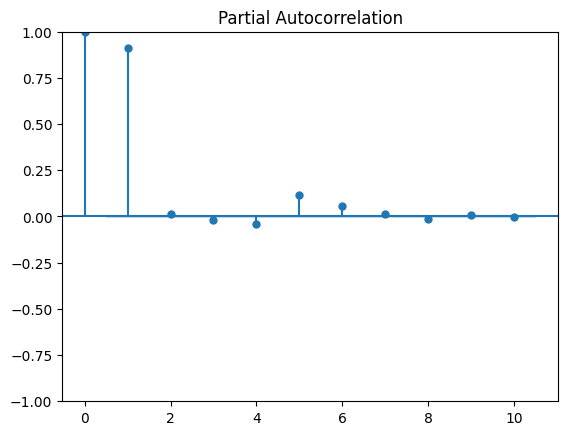

By definition if we find that the coefficients in PCAF plot become abruptly non-significant after a lag p, then we have an autoregressive process. Therefore we can confirm that this is not an ARMA process and it does not make sence to fill this part with sensless code.

It is worth saying that ARMA models assume stationarity and are univariate (they only use past values of the target variable itself). In a steel plant, energy consumption is mostly determined by external factors (production load, reactive power, power factor...) that ARMA cannot incorporate. This is could be the reason why multivariate approaches like SARIMAX with exogenous variables are expected to significantly do it better here.

# ARIMA (General modeling prodedure)
We are going to be following notebook 4.8 available at the ALUD course.



As we are asked to try at least 2 different *p* and *q* configurations, we will use the available functions in the notebook, adapting them to our specific case. We will select the best (*p*, *q*) combinations according to metric AIC (Akaike Information Criterion), which evaluates the quality of the model depending on the goodness of the fit against its complexity. The following code will fit different configurations and return the combinations of the parameters that lower AIC the most.

In [22]:
def optimize_AIC(endog: Union[pd.Series, list], order_list: list, d: int)-> pd.DataFrame:
  results = []
  for order in tqdm(order_list):
    try:
      model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
    except Exception as inst:
      print(inst)
      continue
    aic = model.aic
    results.append([order, aic])
  result_df = pd.DataFrame(results)
  result_df.columns = ['(p,q)', 'AIC']
  result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
  return result_df

ps = range(0, 7, 1)
qs = range(0, 7, 1)
d = 0 # 0 for stationarity, otherwise d would equal to the number of differings applied

order_list = list(product(ps, qs))
result_df = optimize_AIC(train['Usage_kWh'], order_list, d)
result_df

  0%|          | 0/49 [00:00<?, ?it/s]

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

,"(p,q)",AIC
0,"(5, 6)",281591.099705
1,"(4, 6)",281593.789805
2,"(6, 6)",281599.616391
3,"(2, 4)",281608.957918
4,"(5, 4)",281608.988032
5,"(4, 4)",281610.116703
6,"(2, 5)",281610.933221
7,"(3, 4)",281610.939711
8,"(6, 5)",281612.319734
9,"(5, 5)",281612.436408


After the training is completed, we will try with a couple of different configurations to perform further residual analysis. With each of the configurations, we will check whether the residuals are uncorralated and the Q-Q plot shows a straight line. The best values obtained have been ``(5,6) and (4,6)``.

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

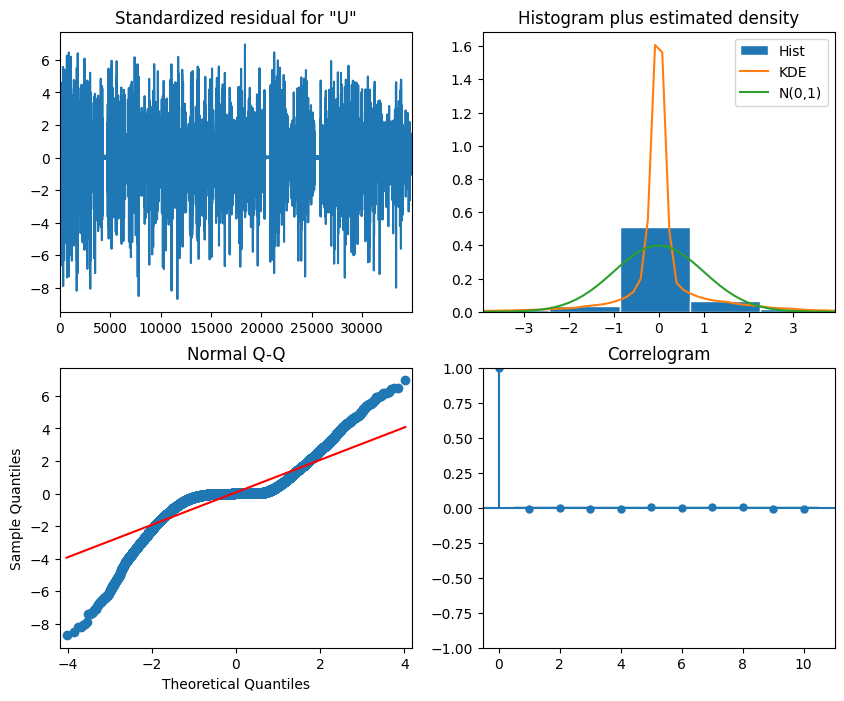

      lb_stat  lb_pvalue
1    1.423581   0.232815
2    2.395344   0.301896
3    3.834542   0.279894
4    5.956664   0.202408
5    6.225781   0.284865
6    6.772358   0.342414
7    7.897905   0.341683
8    8.820829   0.357635
9   10.179190   0.336175
10  11.725480   0.303849


c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

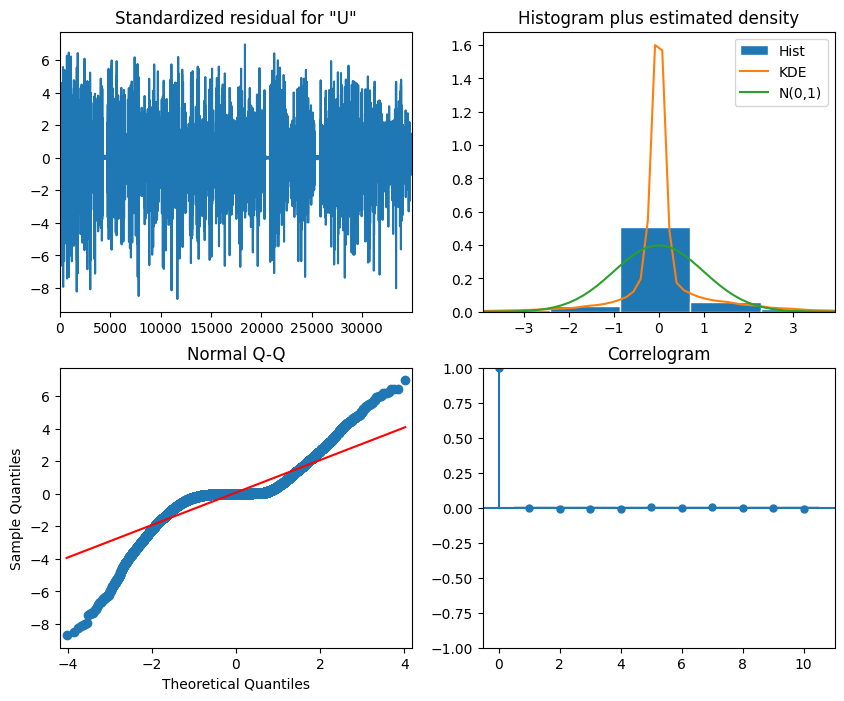

      lb_stat  lb_pvalue
1    0.158718   0.690340
2    2.190004   0.334539
3    3.716292   0.293774
4    7.079790   0.131731
5    9.341551   0.096192
6    9.707680   0.137514
7    9.801273   0.200118
8    9.819957   0.277891
9   10.557809   0.307240
10  13.782551   0.183143


In [23]:
best_configs = np.array([(5,6), (4,6)])

for config in best_configs:
  model = SARIMAX(train["Usage_kWh"], order=(config[0], d, config[1]), simple_differencing=False) # d equals 0 because of its stationarity nature
  model_fit = model.fit(disp=False)
  model_fit.plot_diagnostics(figsize=(10,8))
  plt.show()
  residuals = model_fit.resid #This is where residuals are stored.
  print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))

Neither of the Q-Q plots of the different configurations show a close to perfect straight line, nor any of the p-values of the residuals are lower than the desired threshold. Therefore, we should not advance to the forecasting stage until finding a suitable parameter configuration. 

Even if the results have not been the best, we will still try to forecast and plot the results. 

In [24]:
best_config = best_configs[0]  # Using the first best configuration (5,6)
model = SARIMAX(train["Usage_kWh"], order=(best_config[0], d, best_config[1]), simple_differencing=False)
model_fit = model.fit(disp=False)

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


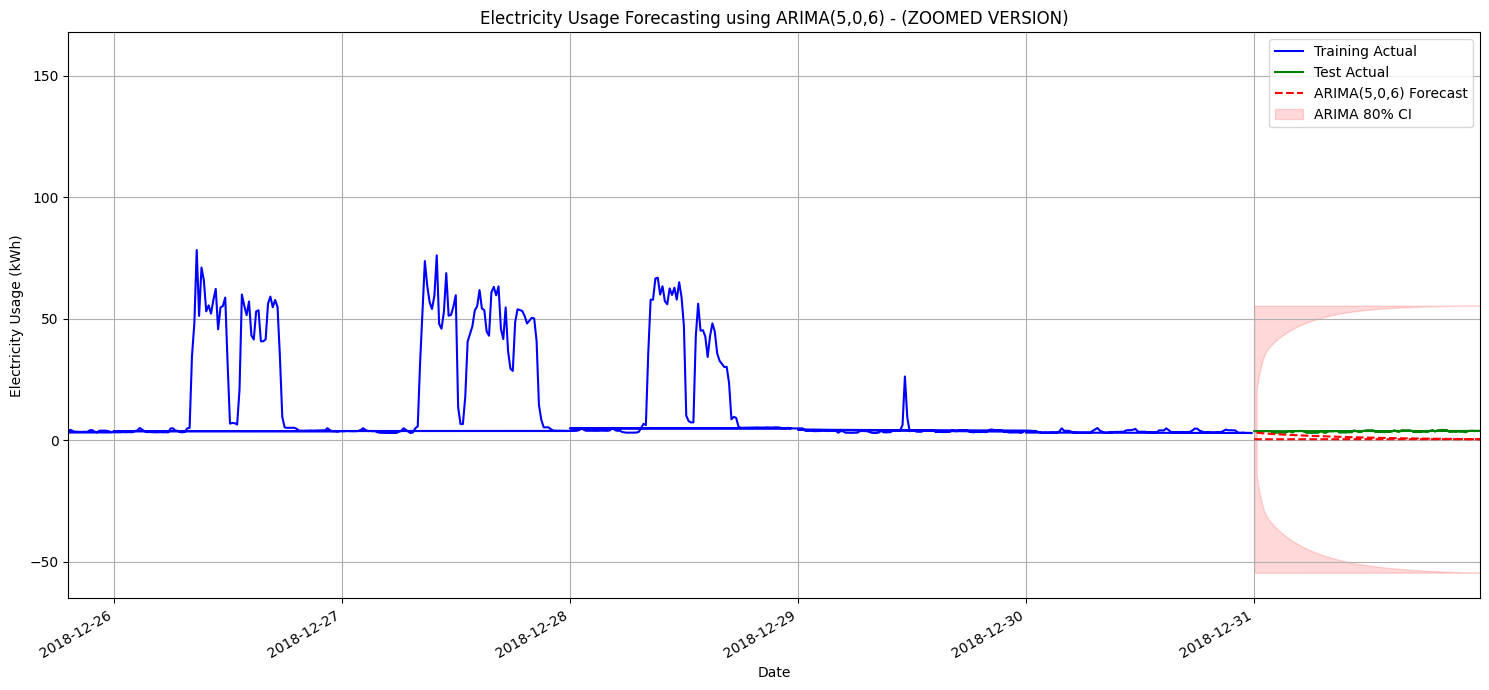

In [25]:
forecast_result = model_fit.get_forecast(steps=test_size)
arima_pred = forecast_result.predicted_mean.values
conf_int = forecast_result.conf_int(alpha=0.2)  # 80% CI
low_10 = conf_int.iloc[:, 0].values
high_90 = conf_int.iloc[:, 1].values
test_plot = test.copy()
test_plot['arima_pred'] = arima_pred

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(train.index, train['Usage_kWh'], 'b-', label='Training Actual')
ax.plot(test_plot.index, test_plot['Usage_kWh'], 'g-', label='Test Actual')
ax.plot(test_plot.index, test_plot['arima_pred'], 'r--', label=f'ARIMA({best_config[0]},{d},{best_config[1]}) Forecast')
ax.fill_between(test_plot.index, low_10, high_90, color='red', alpha=0.15, label='ARIMA 80% CI')

zoom_start_date_index = max(0, len(train) - 500)
zoom_start_date = train.index[zoom_start_date_index]
ax.set_xlim(zoom_start_date, test_plot.index.max())
ax.set_xlabel('Date')
ax.set_ylabel('Electricity Usage (kWh)')
ax.set_title(f'Electricity Usage Forecasting using ARIMA({best_config[0]},{d},{best_config[1]}) - (ZOOMED VERSION)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [26]:
mape_arima = mean_absolute_percentage_error(test_plot['Usage_kWh'], test_plot['arima_pred'])
mse_arima = mean_squared_error(test_plot['Usage_kWh'], test_plot['arima_pred'])
print(f"ARIMA({best_config[0]},{d},{best_config[1]}) Forecasting MAPE: {mape_arima:.4f} Forecasting MSE: {mse_arima:.4f}")

ARIMA(5,0,6) Forecasting MAPE: 0.6399 Forecasting MSE: 6.1015


# SARIMA (General modeling procedure for SARIMA)
We will be following the 4.9 notebook for this procedure. In order to fit the SARIMA model, we must get the best variable configuration. We obtained the best ``(p,d,q)`` values before (5,0,6), now we need to get ``(P,D,Q,S)``. However, we will still perform the search of the variables p, d and q from scratch for the SARIMA example.



*   S stands for the seasonal period. In our cae, we count 15 minute intervals for 24 hours, equaling 96 observations. So in our case ``S=96``.
*   We already obtained ``d=0`` in the previous step, however, for the seasonal differencing order ``D``, we have set it to 1. We have set that value to remove the daily seasonality present in our dataset.

Now we will perform a search for the best values of ``(p,q,P,Q)``.




In [27]:
# Variables we know
d = 0
D = 1
s = 96

ps = range(0, 2)
qs = range(0, 2)
Ps = range(0, 2)
Qs = range(0, 2)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))
SARIMA_order_list # different configurations we will be trying

[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 1, 0),
 (0, 1, 1, 1),
 (1, 0, 0, 0),
 (1, 0, 0, 1),
 (1, 0, 1, 0),
 (1, 0, 1, 1),
 (1, 1, 0, 0),
 (1, 1, 0, 1),
 (1, 1, 1, 0),
 (1, 1, 1, 1)]

In [28]:
# Same function as in the notebook 4.9 xd
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    results = []
    for order in tqdm(order_list):
        try:
            model = SARIMAX(
                endog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue

        aic = model.aic
        results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    # We will also classify the results by a ascending AIC order
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

In [29]:
# Let's try it!
SARIMA_result_df = optimize_SARIMA(train['Usage_kWh'], SARIMA_order_list, d, D, s)

  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

In [30]:
SARIMA_result_df.head()

,"(p,q,P,Q)",AIC
0,"(0, 0, 0, 0)",335334.190542


Although several parameter combinations were defined, only the models that were successfully estimated are shown in the final AIC table. Since the optimization is wrapped inside a try/except block, any configuration that fails during the fitting process is skipped and does not appear in the results.

This behaviour can be related to the computational complexity of the model. In our case, the seasonal period is set to s = 96, which represents a full day of 15-minute observations. This makes the estimation process much heavier in terms of time and memory usage. In some executions, the notebook became unstable and the progress bar did not update properly, probably because the RAM usage was too high. Therefore, the fact that only a few configurations appear in the final table should be interpreted carefully: it does not necessarily mean that only those configurations were tested, but rather that only those configurations were able to finish the fitting process and return an AIC value.

# SARIMAX 




The exogenous variables are those whose value is determined by forces outside the system and are not influenced by the other features of the model. In our case, the following ones are the ones we have categorized as such: 

In [26]:
exog_vars = [
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM'
]

We will be modifying the ``OPTIMIZE_SARIMA`` function, and feeding it our exogenous variables list. Apart from that, it is the same procedure seen in SARIMA.

In [27]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    results = []

    for order in tqdm(order_list):
        try:
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue

        aic = model.aic
        results.append([order, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

In [28]:
d = 0
D = 1
s = 96

# Rangos más pequeños para que sea más rápido
p = range(0, 2)      # [0, 1] en lugar de [0-1]
q = range(0, 2)      # [0, 1]  
P = range(0, 1)      # Solo 0 para P
Q = range(0, 1)      # Solo 0 para Q  

parameters = product(p, q, P, Q)
parameters_list = list(parameters)
print(f"Número de combinaciones a probar: {len(parameters_list)}")
print(f"Combinaciones: {parameters_list}")

Número de combinaciones a probar: 4
Combinaciones: [(0, 0, 0, 0), (0, 1, 0, 0), (1, 0, 0, 0), (1, 1, 0, 0)]


In [29]:
exog_train = train[exog_vars]
exog_test = test[exog_vars]

In [57]:
result_df = optimize_SARIMAX(train['Usage_kWh'], exog_train, parameters_list, d, D, s)
result_df

  0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multivariate-Time-Series-Forecasting-of-Energy-Consumption-in-the-Steel-Industry\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will 

,"(p,q,P,Q)",AIC
0,"(0, 1, 0, 0)",216340.173129


It is important to mention that, although several SARIMAX configurations were defined, not all of them necessarily appear in the final AIC table. This happens because the function only stores the models that are successfully fitted. If a certain combination of parameters fails during the optimization process, it is skipped by the try/except block and therefore it is not included in the results.

In this case, the use of a seasonal component with `s = 96` makes the model computationally expensive, since the data is recorded every 15 minutes and 96 observations represent a complete day. Some parameter combinations may lead to convergence problems or numerical instability during the maximum likelihood estimation. For that reason, obtaining only one row in the final table does not mean that only one configuration was tested, but that only one configuration was successfully estimated and could return an AIC value.

This is probably related to what we previously explained in SARIMA.

In [58]:
result_df.head()

,"(p,q,P,Q)",AIC
0,"(0, 1, 0, 0)",216340.173129


In [31]:
best_model = SARIMAX(train['Usage_kWh'].values, exog_train, order=(0, 0, 1), seasonal_order=(0, 1, 0, 96), simple_differencing=False)
best_model_fit = best_model.fit(disp=False)

/home/unaiolaizolaosa/miniconda3/envs/PFG/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/unaiolaizolaosa/miniconda3/envs/PFG/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/unaiolaizolaosa/miniconda3/envs/PFG/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/unaiolaizolaosa/miniconda3/envs/PFG/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic 

KeyboardInterrupt: 

In [61]:
print(best_model_fit.summary())

NameError: name 'best_model_fit' is not defined

In [ ]:
best_model_fit.plot_diagnostics(figsize=(10,8))

In [ ]:
residuals = best_model_fit.resid
print(acorr_ljungbox(residuals, np.arange(1, 13, 1)))

In [ ]:
def rolling_forecast(endog: Union[pd.Series, list], exog: Union[pd.Series, list], train_len: int, horizon: int, window: int, method: str, p: int = None, d_order: int = None, q: int = None, P: int = None, D_order: int = None, Q: int = None, s: int = None) -> list:
    total_len = train_len + horizon
    if method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = endog.iloc[i-1]
            pred_last_value.extend([last_value] * window)
        return pred_last_value[:horizon]

    elif method == 'SARIMAX':
        pred_SARIMAX = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog=exog[:i], order=(p, d_order, q), seasonal_order=(P, D_order, Q, s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(exog=exog)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMAX.extend(oos_pred)
        return pred_SARIMAX[:horizon]

In [ ]:
# Prepare rolling forecast data
exog_all = df[exog_vars]
target = df['Usage_kWh']

pred_df = pd.DataFrame({'actual': test['Usage_kWh'].values})
TRAIN_LEN = len(train)
HORIZON = len(test)  # How many steps into the future
WINDOW = 1  # Size of each step

pred_last_value = rolling_forecast(target, exog_all, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_SARIMAX = rolling_forecast(target, exog_all, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX', 
                                p=best_params[0], d_order=d, q=best_params[1], 
                                P=best_params[2], D_order=D, Q=best_params[3], s=s)
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_SARIMAX'] = pred_SARIMAX
pred_df

In [ ]:
mape_sarimax = mean_absolute_percentage_error(pred_df.actual, pred_df.pred_SARIMAX)
mse_sarimax = mean_squared_error(pred_df.actual, pred_df.pred_SARIMAX)

print(mape_last, mse_last, mape_sarimax, mse_sarimax)

### Alternative: AUTOARIMA 

In [ ]:
from pmdarima import auto_arima

# This automatically searches parameter space efficiently
auto_model = auto_arima(train['Usage_kWh'], exogenous=exog_train,
                        max_p=2, max_q=2, max_P=2, max_Q=2, m=96,
                        seasonal=True, stepwise=True, trace=True)

Performing stepwise search to minimize aic


# Transformer based architecture: Chronos
After studying the two transformer based forecasting models in class, we will go with the one reported to work better than the other: Chronos. We will also use the same T5 encoder-decoder model seen in class.

In [11]:
# Let's ensure we have cuda available first
print(torch.cuda.is_available())

True


In [14]:
# Same t5 model used in the 4.12 notebook
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map='cuda' if torch.cuda.is_available() else 'cpu',
    torch_dtype=torch.bfloat16,
)

The steps to complete the forecast procedure will be the same as in class.


1.   Creating the context tensor to feed the transformer
2.   Calling the prediction function
3.   We will be extracting the median forecast.





In [17]:
# Step 1
context_tensor = torch.tensor(train["Usage_kWh"].values, dtype=torch.float32)

# Step 2
forecast = pipeline.predict(context_tensor.unsqueeze(0),
                            prediction_length=test_size,
                            num_samples=100)

# Step 3
median_forecast = forecast[0].median(dim=0).values.numpy()

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


Finally, let's plot the forecasted values of the dataset!

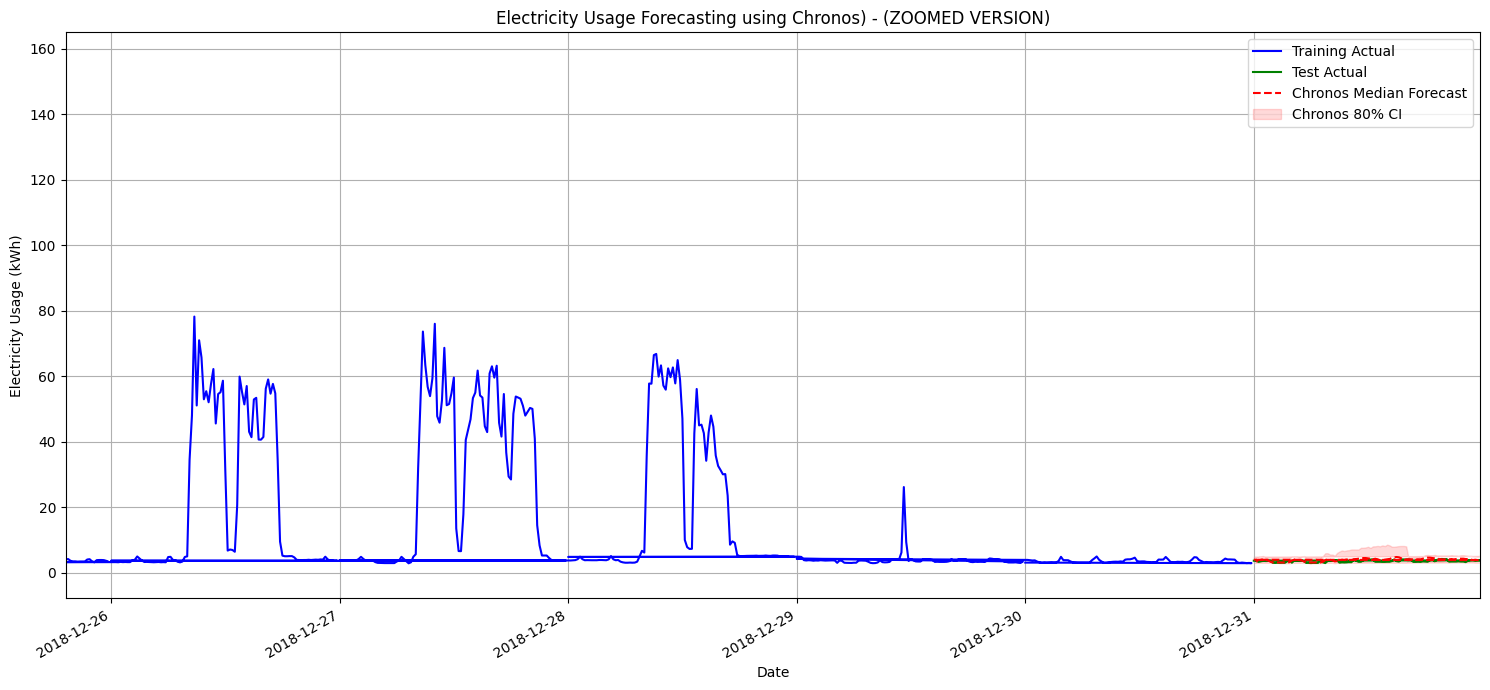

In [24]:
test = test.copy()

low_10 = forecast[0].quantile(0.1, dim=0).numpy()
high_90 = forecast[0].quantile(0.9, dim=0).numpy()

test['naive_seasonal'] = train['Usage_kWh'].iloc[-test_size:].values
test['chronos_pred'] = median_forecast

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(train.index, train['Usage_kWh'].values, 'b-', label='Training Actual')
ax.plot(test.index, test['Usage_kWh'], 'g-', label='Test Actual')
ax.plot(test.index, test['chronos_pred'], 'r--', label='Chronos Median Forecast')
ax.fill_between(test.index, low_10, high_90, color='red', alpha=0.15, label='Chronos 80% CI')
zoom_start_date_index = max(0, len(train) - 500)
zoom_start_date = train.index[zoom_start_date_index]
ax.set_xlim(zoom_start_date, test.index.max())
ax.set_xlabel('Date')
ax.set_ylabel('Electricity Usage (kWh)')
ax.set_title('Electricity Usage Forecasting using Chronos) - (ZOOMED VERSION)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Let's evaluate the performance using the *mean absolute percentage* error.

In [25]:
mape_chronos = mean_absolute_percentage_error(test['Usage_kWh'], test['chronos_pred'])
print(f"Chronos Forecasting MAPE: {mape_chronos:.4f}")

mse_chronos = mean_squared_error(test['Usage_kWh'], test['chronos_pred'])
print(f"Chronos Forecasting MSE: {mse_chronos:.4f}")

Chronos Forecasting MAPE: 0.1342
Chronos Forecasting MSE: 0.3281


In [ ]:
table = pd.DataFrame(columns=['Process', 'MAPE', 'MAE'])

table = pd.concat([table, pd.DataFrame([{
    'Process': 'Baseline - Mean',
    'MAPE': mean_absolute_percentage_error(test['Usage_kWh'], test['pred_mean']),
    'MSE':  mean_squared_error(test['Usage_kWh'], test['pred_mean'])
}])], ignore_index=True)
table = pd.concat([table, pd.DataFrame([{
    'Process': 'Baseline - Last Value',
    'MAPE': mape_last,
    'MSE':  mse_last
}])], ignore_index=True)
table = pd.concat([table, pd.DataFrame([{
    'Process': 'Baseline - AR(1)',
    'MAPE': mape_AR,
    'MSE':  mse_AR
}])], ignore_index=True)
# --- ARIMA ---
table = pd.concat([table, pd.DataFrame([{
    'Process': f'ARIMA({best_config[0]},{d},{best_config[1]})',
    'MAPE': mape_arima,
    'MSE':  mse_arima
}])], ignore_index=True)
# --- SARIMAX ---
table = pd.concat([table, pd.DataFrame([{
    'Process': 'SARIMAX',
    'MAPE': mape_sarimax,
    'MSE':  mse_sarimax
}])], ignore_index=True)
# --- Chronos ---
table = pd.concat([table, pd.DataFrame([{
    'Process': 'Chronos',
    'MAPE': mape_chronos,
    'MSE': mse_chronos
}])], ignore_index=True)
table.style.format({'MAPE': '{:.4f}', 'MAE': '{:.4f}'}).highlight_min(
    subset=['MAPE', 'MAE'], color='lightgreen'
)

table.head()

## Results Discussion

Here is a summary of the forecasting model performance using Mean Absolute Percentage Error (MAPE) and Mean Squared Error (MSE):

| Process               | MAPE      | MSE       |
| :-------------------- | :-------- | :-------- |
|  Mean       | 0.8712    | 570.7704  |
|  Last Value | 0.0670    | 0.1225    |
|  AR(1, 0, 0)      | 0.1199    | 0.2019    |
| ARIMA(5,0,6)          | 0.6399    | 6.1015    |
| SARIMAX               | N/A       | N/A       |
| Autoarima               | N/A       | N/A       |
| Chronos               | 0.1342   | 0.3281      |


**Interesting Findings:**
*   The 'Baseline - Last Value' model performed remarkably well, indicating a strong short-term dependency in the data, likely due to the plant's operational patterns.
*   The ARIMA model, despite optimization, showed higher error metrics compared to the simpler baseline models, suggesting that its assumptions might not fully capture the underlying data dynamics or that external factors play a significant role.
*   The Chronos model, a transformer-based approach, yielded a competitive MAPE, highlighting the potential of more complex deep learning models for this dataset, even without explicit exogenous variables for this particular run.
*   The significant differences in performance between models (e.g., mean vs. last value) underscore the importance of selecting appropriate 'naive' strategies based on data characteristics.

In [ ]:
# We initially wanted to show the results like this, but we will input the hard-coded output values to not re-run everything
table = pd.DataFrame(columns=['Process', 'MAPE', 'MAE'])

table = pd.concat([table, pd.DataFrame([{
    'Process': 'Baseline - Mean',
    'MAPE': mean_absolute_percentage_error(test['Usage_kWh'], test['pred_mean']),
    'MSE':  mean_squared_error(test['Usage_kWh'], test['pred_mean'])
}])], ignore_index=True)
table = pd.concat([table, pd.DataFrame([{
    'Process': 'Baseline - Last Value',
    'MAPE': mape_last,
    'MSE':  mse_last
}])], ignore_index=True)
table = pd.concat([table, pd.DataFrame([{
    'Process': 'Baseline - AR(1)',
    'MAPE': mape_AR,
    'MSE':  mse_AR
}])], ignore_index=True)
# --- ARIMA ---
table = pd.concat([table, pd.DataFrame([{
    'Process': f'ARIMA({best_config[0]},{d},{best_config[1]})',
    'MAPE': mape_arima,
    'MSE':  mse_arima
}])], ignore_index=True)
# --- SARIMAX ---
table = pd.concat([table, pd.DataFrame([{
    'Process': 'SARIMAX',
    'MAPE': mape_sarimax,
    'MSE':  mse_sarimax
}])], ignore_index=True)
# --- Chronos ---
table = pd.concat([table, pd.DataFrame([{
    'Process': 'Chronos',
    'MAPE': mape_chronos,
    'MSE': mse_chronos
}])], ignore_index=True)
table.style.format({'MAPE': '{:.4f}', 'MAE': '{:.4f}'}).highlight_min(
    subset=['MAPE', 'MAE'], color='lightgreen'
)

table.head()

# Lessons learned




We drew some inconclusive results about whether our time series was a random walk or not due to some inconclusive visualiztion, however, we came into a conclusion it was not and we reflected on that in this second deliverable.

Another point which resulted frustrating was the huge amount of RAM memory needed to fit the different forecasting model parameters combinattion. We had a challenge as the memory would collapse both in *Google Colab* and locally. Nevertheless, trying it with 64 resulted successful. The reason of the collapse is linked to the amount of points processed and the different parameter configurations tried, so we did have to reduce those ranges to make it computationally feasible.

Even if the forecasts were not the best, we are proud of our work and happy with the results obtained.

Regarding the specific parameter we chose and how we used them, they are duly explained in their corresponding parts for a better comprehesion.

# References

https://medium.com/@heyamit10/time-series-decomposition-in-python-049b72a00ba0

https://mcpanalytics.ai/whitepapers/whitepaper-seasonal-decomposition

https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

Notebooks available at ALUD: https://alud.deusto.es/course/view.php?id=33806
